<a href="https://colab.research.google.com/github/hema841/titanic-dataset-analysis/blob/main/Iris_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Iris.csv to Iris (1).csv
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
(150, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
m

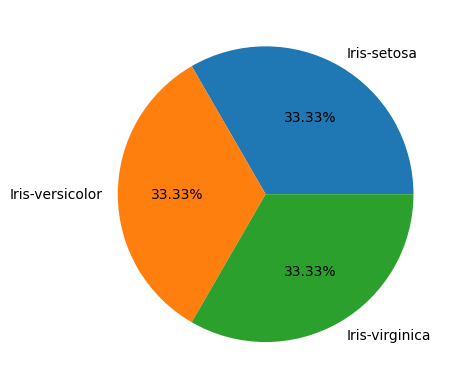

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0            5.1           3.5            1.4           0.2        2
1            4.9           3.0            1.4           0.2        2
2            4.7           3.2            1.3           0.2        2
3            4.6           3.1            1.5           0.2        2
4            5.0           3.6            1.4           0.2        2
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64
3
0


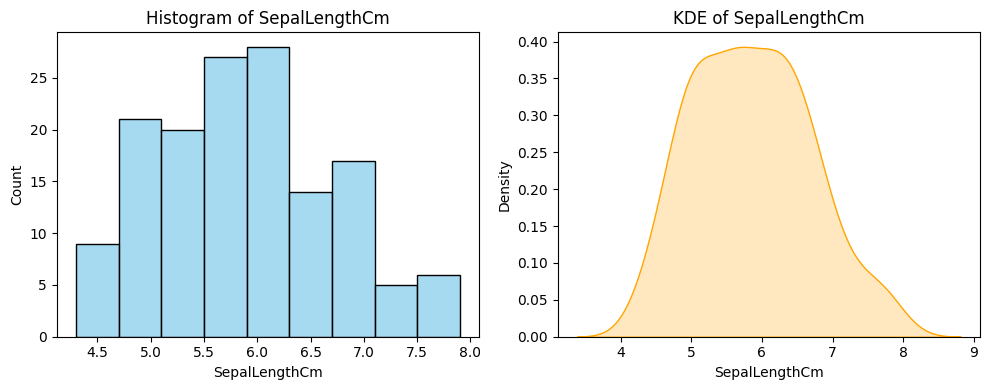

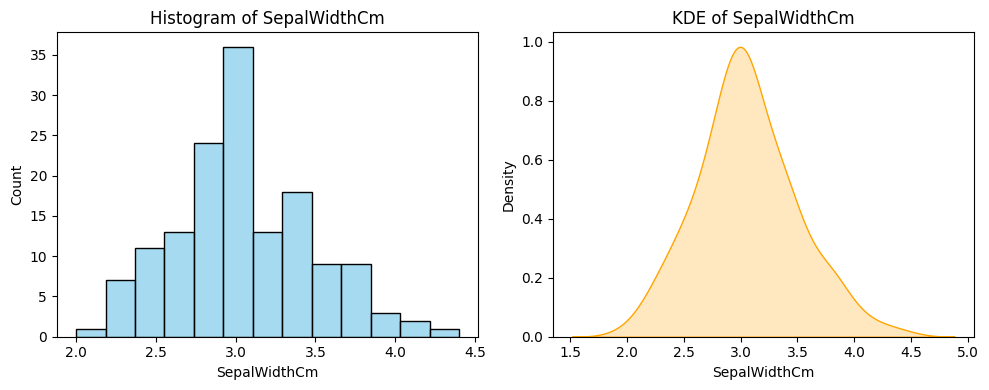

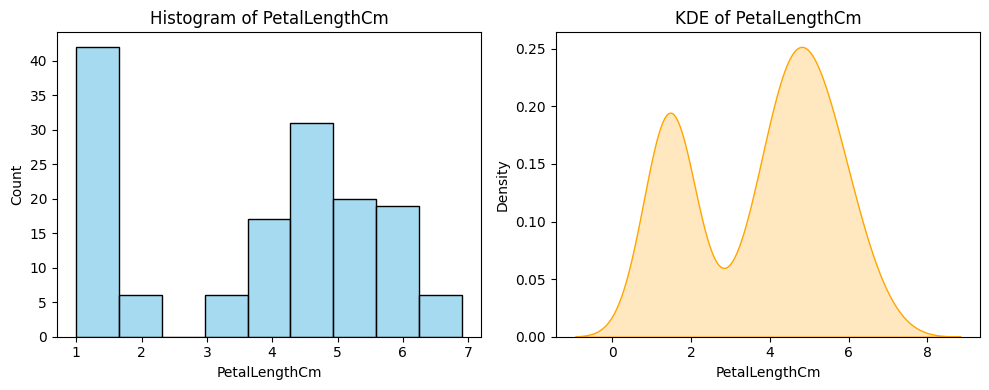

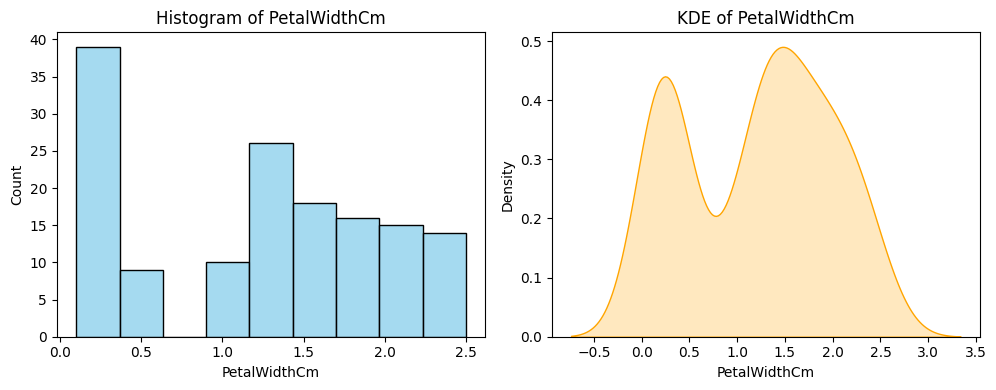

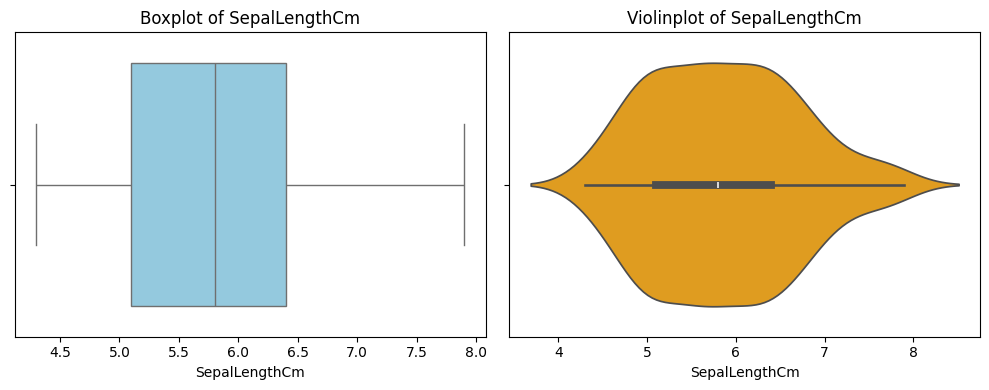

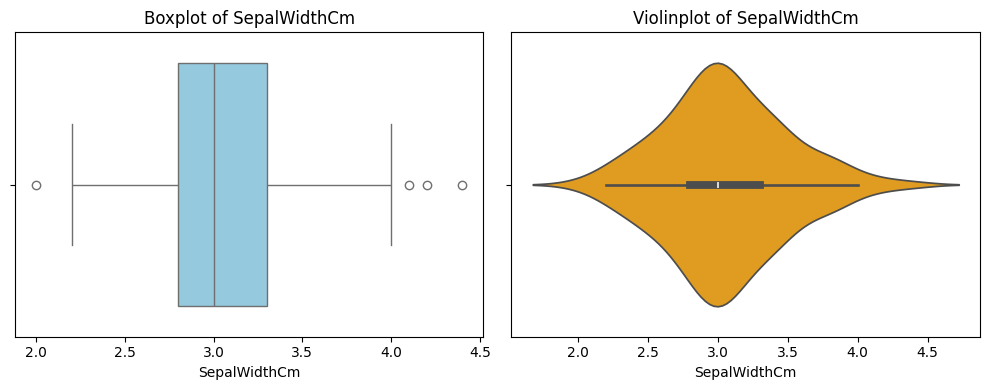

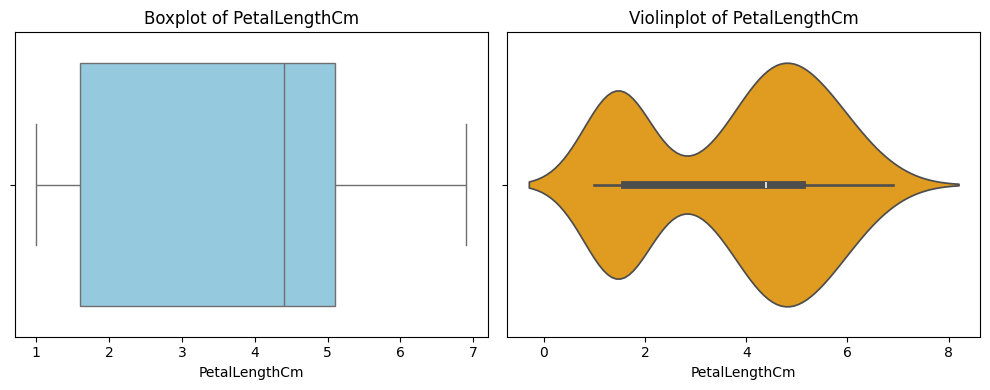

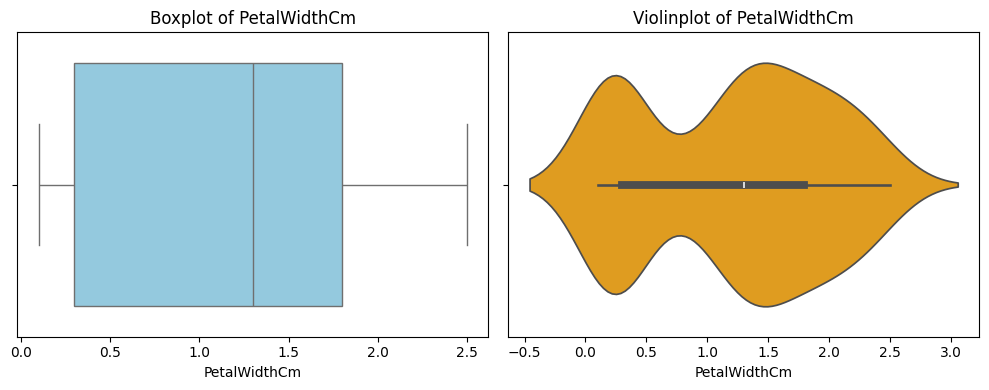

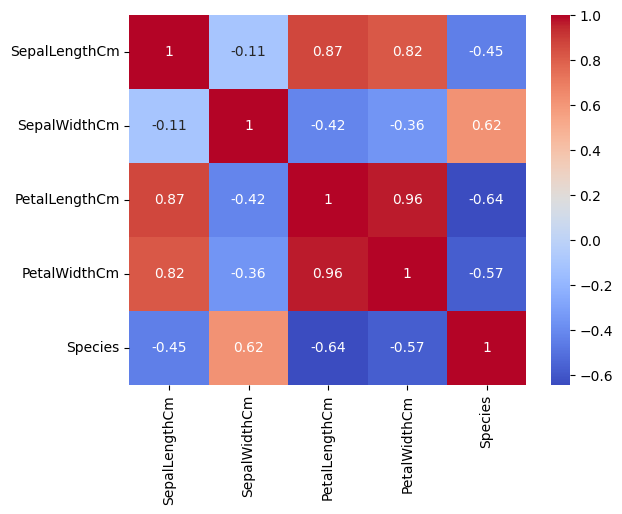

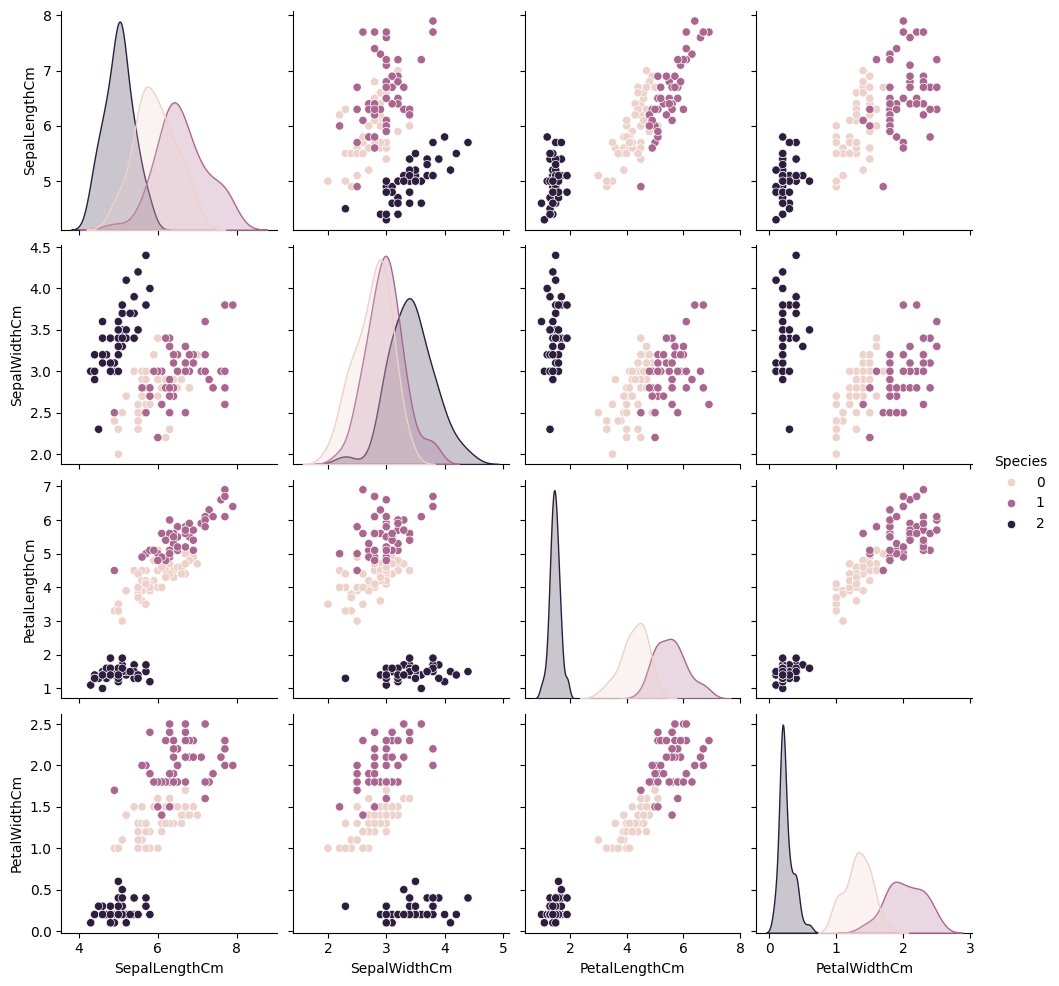

Logistic Regression
Cross Validation Accuracy: 0.9572463768115942
Test Accuracy: 0.9333333333333333
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        10
           1       0.89      0.89      0.89         9
           2       1.00      1.00      1.00        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



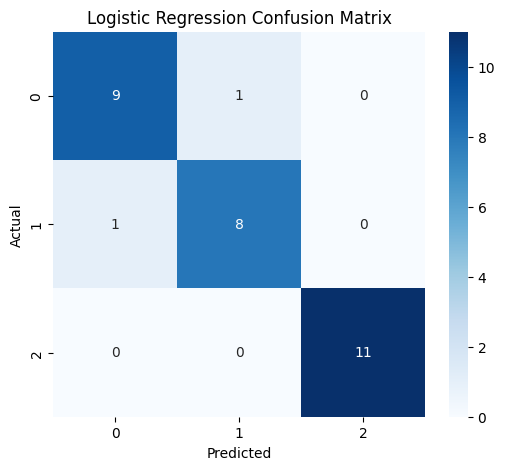

Naive Bayes
Cross Validation Accuracy: 0.9572463768115942
Test Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.89      0.94         9
           2       1.00      1.00      1.00        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.96        30
weighted avg       0.97      0.97      0.97        30



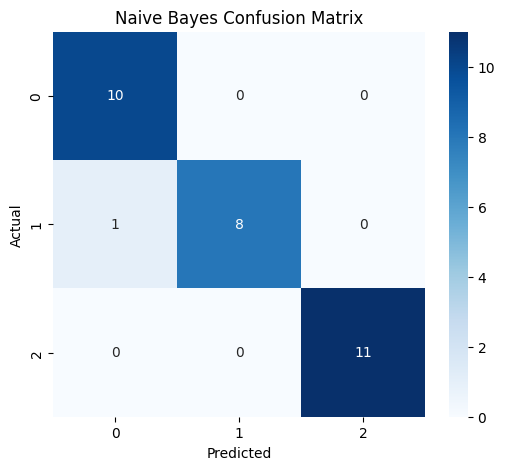

SVM
Cross Validation Accuracy: 0.9742753623188406
Test Accuracy: 0.9666666666666667
              precision    recall  f1-score   support

           0       1.00      0.90      0.95        10
           1       0.90      1.00      0.95         9
           2       1.00      1.00      1.00        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



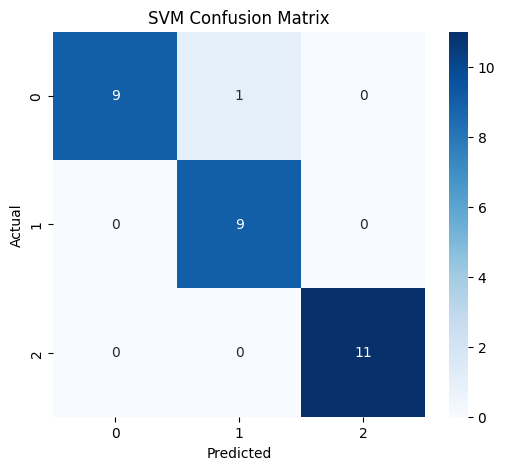

In [3]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

uploaded = files.upload()

df = pd.read_csv("Iris.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.describe().T)

print(df['Species'].unique())
print(df['Species'].value_counts())

plt.pie(
    x=df['Species'].value_counts().values,
    labels=df['Species'].value_counts().index,
    autopct='%.2f%%'
)
plt.show()

target = {
    'Iris-versicolor': 0,
    'Iris-virginica': 1,
    'Iris-setosa': 2
}

df['Species'] = df['Species'].map(target)

if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

print(df.head())

print(df.isna().sum())
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print(df.duplicated().sum())

num_col = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
num_col.remove('Species')

for col in num_col:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.histplot(df[col], color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')

    plt.subplot(1, 2, 2)
    sns.kdeplot(df[col], fill=True, color='orange')
    plt.title(f'KDE of {col}')

    plt.tight_layout()
    plt.show()

for col in num_col:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')

    plt.subplot(1, 2, 2)
    sns.violinplot(x=df[col], color='orange')
    plt.title(f'Violinplot of {col}')

    plt.tight_layout()
    plt.show()

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

sns.pairplot(data=df, hue='Species')
plt.show()

X = df.drop(columns=['Species'])
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(C=1.0)

cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Logistic Regression")
print("Cross Validation Accuracy:", np.mean(cv_scores))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

nb_model = GaussianNB()

nb_cv_scores = cross_val_score(nb_model, X_train_scaled, y_train, cv=5)

nb_model.fit(X_train_scaled, y_train)

nb_pred = nb_model.predict(X_test_scaled)

print("Naive Bayes")
print("Cross Validation Accuracy:", np.mean(nb_cv_scores))
print("Test Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

svm_model = SVC(kernel='linear', C=1.0, random_state=42)

svm_cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5)

svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)

print("SVM")
print("Cross Validation Accuracy:", np.mean(svm_cv_scores))
print("Test Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()